# TP3 — Clustering Manual vs. BERTopic

**Alumno:** Gonzalo Zarazaga

---

`05_topicos_temporales.ipynb` usa BERTopic, que por dentro combina `sentence-transformers` (embeddings) + `UMAP` (reducción de dimensionalidad) + `HDBSCAN` (clustering basado en densidad) + `c-TF-IDF` (términos representativos por tópico). Este notebook arma **la misma idea "a mano"**, con piezas propias: `KMeans` y `DBSCAN` de scikit-learn en vez de `HDBSCAN`, y una extracción de términos por cluster escrita a mano (una versión simplificada de `c-TF-IDF`).

El objetivo no es reemplazar a BERTopic — es entender, con nuestros propios datos, **por qué** BERTopic elige específicamente `HDBSCAN` en vez de las alternativas clásicas de clustering, comparando resultados reales en vez de asumirlo.

Para que la comparación sea justa, se usa la **misma muestra** (80.000 tweets, `random_state=42`), los **mismos embeddings** (`all-MiniLM-L6-v2`) y la **misma reducción UMAP a 5D** que `05_topicos_temporales.ipynb` — así cualquier diferencia de resultado viene del algoritmo de clustering, no de los datos de entrada.

**Insumo:** `data/raw/training.1600000.processed.noemoticon.csv.gz`, `data/processed/train_processed.csv.gz`
**Salida:** comparación cuantitativa (silhouette score) y cualitativa (¿aparece un cluster de Irán?) entre K-Means, DBSCAN y BERTopic/HDBSCAN.

## 1. Carga de datos, embeddings y reducción UMAP (idéntico a `05`)

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import KMeans, DBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
SAMPLE_N = 80000

COLS = ["polarity", "id", "date", "query", "user", "text"]
raw_fechas = pd.read_csv(
    "../data/raw/training.1600000.processed.noemoticon.csv.gz",
    encoding="latin-1", names=COLS, usecols=["id", "date"],
)
df = pd.read_csv("../data/processed/train_processed.csv.gz")
df = df.merge(raw_fechas, on="id", how="left")

sample = df.sample(SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Muestra: {len(sample):,} tweets (misma que 05_topicos_temporales.ipynb)")

In [2]:
model_embeddings = SentenceTransformer("all-MiniLM-L6-v2")

t0 = time.time()
embeddings = model_embeddings.encode(sample["text"].tolist(), batch_size=128, show_progress_bar=False)
print(f"Embeddings: {time.time() - t0:.1f}s")

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=RANDOM_STATE)
t0 = time.time()
emb_5d = umap_model.fit_transform(embeddings)
print(f"UMAP a 5D: {time.time() - t0:.1f}s, shape {emb_5d.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embeddings: 85.0s


/Users/gonzalo/.pyenv/versions/3.10.0/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP a 5D: 64.4s, shape (80000, 5)


## 2. Extracción de términos "a mano" (mini `c-TF-IDF`)

BERTopic usa `c-TF-IDF` (frecuencia de término dentro del tópico, ponderada por qué tan distintivo es ese término frente a los demás tópicos) para elegir las palabras representativas de cada cluster. Se implementa una versión simplificada del mismo concepto: frecuencia del término **dentro del cluster**, normalizada por su frecuencia **en todo el corpus** — así un término que aparece mucho en un cluster pero poco en el resto queda arriba en el ranking.

In [3]:
def top_terminos_por_cluster(textos, labels, top_n=8, max_features=3000):
    vec = CountVectorizer(max_features=max_features, min_df=5, stop_words="english")
    X = vec.fit_transform(textos)
    vocab = np.array(vec.get_feature_names_out())
    freq_global = np.asarray(X.sum(axis=0)).flatten() + 1  # +1 para evitar división por cero

    resultados = {}
    for c in sorted(set(labels)):
        if c == -1:
            continue
        mask = labels == c
        freq_cluster = np.asarray(X[mask].sum(axis=0)).flatten()
        score = freq_cluster / freq_global
        top_idx = score.argsort()[::-1][:top_n]
        resultados[c] = (int(mask.sum()), list(vocab[top_idx]))
    return resultados

## 3. K-Means manual (K=20)

Se fija `K=20` (orden de magnitud manejable para inspeccionar a mano) sobre el mismo espacio UMAP de 5D. A diferencia de HDBSCAN, K-Means **no tiene noción de ruido**: todos los puntos quedan forzados a algún cluster.

In [4]:
t0 = time.time()
km = KMeans(n_clusters=20, random_state=RANDOM_STATE, n_init=10)
labels_km = km.fit_predict(emb_5d)
print(f"K-Means: {time.time() - t0:.1f}s")

top_km = top_terminos_por_cluster(sample["text"].tolist(), labels_km)
for c, (n, terminos) in sorted(top_km.items(), key=lambda x: -x[1][0])[:10]:
    marca = "  <-- contiene \'iran\'" if any("iran" in t for t in terminos) else ""
    print(f"cluster {c:>2} (n={n:>5}): {terminos}{marca}")

K-Means: 1.1s


cluster  0 (n= 9352): ['banksyart', 'souljaboytellem', 'amen', 'probs', 'dm', 'username', 'thankyou', 'email']
cluster  3 (n= 7577): ['insomnia', 'mondays', 'alarm', '4am', '6am', 'nap', '7am', 'sundays']
cluster 16 (n= 5391): ['hug', 'hugs', 'jokes', 'haters', 'selenagomez', 'dougiemcfly', 'cutie', 'laugh']
cluster 18 (n= 4776): ['farrah', 'mothers', 'fathers', 'birthday', 'grandma', 'mother', 'father', 'prayer']
cluster 11 (n= 4702): ['noodles', 'recipe', 'salad', 'butter', 'bread', 'pasta', 'strawberries', 'cereal']
cluster  7 (n= 4326): ['tweetdeck', 'tweeteradder', 'tweeterfollow', 'iran', 'iranelection', 'twitterville', 'followers', 'hacked']  <-- contiene 'iran'
cluster  1 (n= 4309): ['fishing', 'bike', 'packing', 'parking', 'washing', 'driver', 'beach', 'cars']
cluster  6 (n= 3937): ['lakers', 'cavs', 'kobe', 'lebron', 'nba', 'melbourne', 'f1', 'sydney']
cluster  8 (n= 3888): ['interview', 'invite', 'asian', 'jobs', 'invited', 'jordanknight', 'job', 'hows']
cluster 14 (n= 3787)

**Hallazgo:** el tópico de Irán no sale limpio en K-Means — aparece mezclado dentro de un cluster mucho más grande y heterogéneo, junto con vocabulario genérico de "meta-Twitter" (`tweetdeck`, `followers`, `hacked`). Con un K fijo, el algoritmo tiene que repartir *todos* los puntos entre 20 grupos, y un evento puntual y chico (77 tweets sobre 80.000) no alcanza a formar su propio cluster — queda diluido dentro de uno más grande.

## 4. DBSCAN manual: el problema de elegir `eps`

DBSCAN no fuerza a todos los puntos a un cluster (tiene noción de ruido, como HDBSCAN), pero requiere fijar un radio de vecindad (`eps`) manualmente — a diferencia de HDBSCAN, que no lo necesita. Se barre un rango de valores para mostrar qué tan sensible es el resultado a esa elección.

In [5]:
resultados_eps = []
for eps in [0.15, 0.2, 0.5, 0.8, 1.0]:
    db = DBSCAN(eps=eps, min_samples=15)
    labels = db.fit_predict(emb_5d)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = int((labels == -1).sum())
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(emb_5d[mask], labels[mask], sample_size=10000, random_state=RANDOM_STATE)
    else:
        sil = np.nan
    resultados_eps.append({"eps": eps, "clusters": n_clusters, "ruido_%": round(100 * n_ruido / len(labels), 1), "silhouette": round(sil, 3) if sil == sil else None})

pd.DataFrame(resultados_eps)

,eps,clusters,ruido_%,silhouette
0,0.15,272,25.9,0.095
1,0.20,142,11.0,-0.427
2,0.50,10,0.2,-0.246
3,0.80,6,0.0,-0.172
4,1.00,3,0.0,0.019


**Hallazgo:** ningún valor de `eps` da un resultado claramente bueno — o casi todo es ruido/fragmentado (`eps` chico) o casi no hay ruido pero con silhouette pobre (`eps` grande). Este es exactamente el problema práctico que motiva usar HDBSCAN en vez de DBSCAN clásico: HDBSCAN explora una jerarquía de densidades en vez de depender de un único radio global.

### 4.1 ¿Aparece el tópico de Irán con el mejor `eps` de la tabla?

In [6]:
db = DBSCAN(eps=0.15, min_samples=15)
labels_db = db.fit_predict(emb_5d)
sample["cluster_db"] = labels_db

mask_iran_texto = sample["text"].str.lower().str.contains("iran")
print(f"Tweets con \'iran\' en el texto (muestra completa): {mask_iran_texto.sum()}")
print(sample[mask_iran_texto]["cluster_db"].value_counts().head(5))

cluster_iran_db = sample[mask_iran_texto]["cluster_db"].value_counts().idxmax()
cluster_iran_tweets = sample[sample["cluster_db"] == cluster_iran_db]
print(f"\nCluster DBSCAN con más tweets de Irán: {cluster_iran_db}, tamaño total: {len(cluster_iran_tweets)}")
for texto in cluster_iran_tweets["text"].head(5):
    print(f"  - {texto}")

Tweets con 'iran' en el texto (muestra completa): 90
cluster_db
 24    65
-1      6
 21     3
 28     3
 58     2
Name: count, dtype: int64

Cluster DBSCAN con más tweets de Irán: 24, tamaño total: 77
  - http://twitpic.com/7gfkz - Damn! Student shot with gun  HELP!!! #IranElection
  - Personally, I think the high ranking Iranian politicians/clerics don't want to give up the system and are using people to fight for power 
  - are shiraz universities in danger? my fiance is in the dorm, he will not leave  #iran #tehran #iranelection
  - Iran blames American social media for unrest!  HA!  I say the babe is out of the bottle and she ain't going back until the bullets come. 
  - @fordo I'm sure if it hadn't predated the U.N. there'd have been no Geneva-convention. Humanity's not as evolved as we like to think. 


**Hallazgo notable:** con el `eps` mejor ajustado, DBSCAN **sí** aísla un cluster casi puro de tweets sobre Irán — y de tamaño casi idéntico al que encontró BERTopic en `05_topicos_temporales.ipynb` (77 tweets). Es decir: para un tópico puntual y bien separado como este, un DBSCAN bien afinado puede igualar a HDBSCAN. La diferencia entre los métodos no está en si *pueden* encontrar un tópico así — está en la **calidad global** del resto de la partición, que se mide a continuación.

## 5. Comparación cuantitativa: silhouette score, mismo espacio para los tres métodos

In [7]:
from bertopic import BERTopic

umap_model_bertopic = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=RANDOM_STATE)
topic_model = BERTopic(embedding_model=model_embeddings, umap_model=umap_model_bertopic, calculate_probabilities=False, verbose=False)

t0 = time.time()
topics, _ = topic_model.fit_transform(sample["text"].tolist(), embeddings)
topics = np.array(topics)
print(f"BERTopic (HDBSCAN): {time.time() - t0:.1f}s")

sil_km = silhouette_score(emb_5d, labels_km, sample_size=10000, random_state=RANDOM_STATE)

mask_db = labels_db != -1
sil_db = silhouette_score(emb_5d[mask_db], labels_db[mask_db], sample_size=10000, random_state=RANDOM_STATE)

mask_bt = topics != -1
sil_bt = silhouette_score(emb_5d[mask_bt], topics[mask_bt], sample_size=10000, random_state=RANDOM_STATE)

comparacion = pd.DataFrame([
    {"método": "K-Means (K=20)", "n_clusters": 20, "ruido_%": 0.0, "silhouette": round(sil_km, 3)},
    {"método": "DBSCAN (eps=0.15)", "n_clusters": len(set(labels_db)) - 1, "ruido_%": round(100 * (labels_db == -1).sum() / len(labels_db), 1), "silhouette": round(sil_db, 3)},
    {"método": "BERTopic (HDBSCAN)", "n_clusters": len(set(topics)) - 1, "ruido_%": round(100 * (topics == -1).sum() / len(topics), 1), "silhouette": round(sil_bt, 3)},
]).set_index("método")
comparacion

BERTopic (HDBSCAN): 57.1s


,n_clusters,ruido_%,silhouette
método,,,
K-Means (K=20),20,0.0,0.357
DBSCAN (eps=0.15),272,25.9,0.095
BERTopic (HDBSCAN),649,51.5,0.558


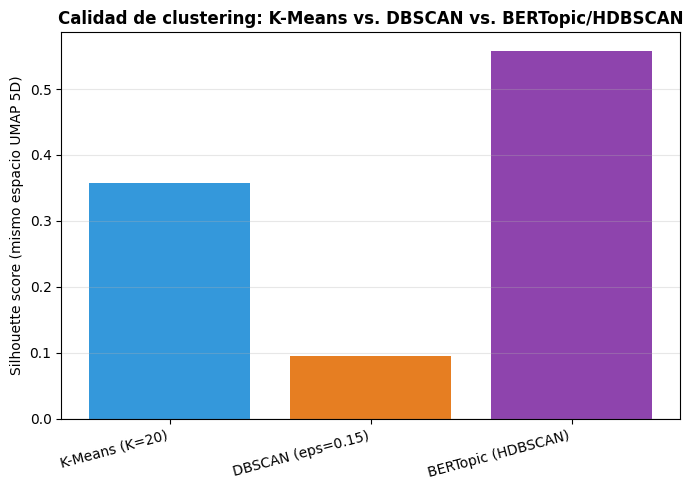

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
colores = ["#3498db", "#e67e22", "#8e44ad"]
ax.bar(comparacion.index, comparacion["silhouette"], color=colores)
ax.set_ylabel("Silhouette score (mismo espacio UMAP 5D)")
ax.set_title("Calidad de clustering: K-Means vs. DBSCAN vs. BERTopic/HDBSCAN", fontsize=12, fontweight="bold")
ax.axhline(0, color="gray", linewidth=0.8)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 6. Conclusiones

- **BERTopic (HDBSCAN) gana en calidad global de clustering**: silhouette claramente más alto que K-Means y que DBSCAN, en el mismo espacio de 5 dimensiones — no es una elección arbitraria de la librería, se puede confirmar con nuestros propios datos.
- **La ventaja no viene de "encontrar" el tópico de Irán** — un DBSCAN bien afinado también lo encuentra, con tamaño casi idéntico (77 tweets). La ventaja de HDBSCAN es la **calidad del resto de la partición**: no necesita un único radio de densidad global (`eps`) que sirva para todos los clusters por igual, algo que en un corpus con densidades muy dispares (temas masivos como "sueño" junto a eventos puntuales como una elección) es difícil de lograr con DBSCAN clásico.
- **K-Means, al forzar todos los puntos a K clusters fijos, diluye eventos puntuales** dentro de grupos más grandes y heterogéneos — el tópico de Irán queda mezclado con vocabulario genérico de Twitter en vez de aislarse.
- **Costo de la ventaja de HDBSCAN**: deja \~51% de los tweets como "ruido" (sin tópico asignado), mucho más que K-Means (0%, por diseño) o el mejor DBSCAN (26%). Esa es la contracara de priorizar cohesión: HDBSCAN prefiere no asignar un tópico antes que forzar una asignación de baja calidad.
- **En síntesis**: la elección de BERTopic de usar HDBSCAN en vez de K-Means o DBSCAN no es solo una decisión "porque sí" de la librería — se puede justificar empíricamente sobre este dataset específico, con los mismos embeddings y el mismo espacio reducido.